# Phase 6: Machine Learning
## London Airbnb Analysis - Mohan Raju Kolikonda
Predicting whether a listing will be a High performer, to support acquistion decisions

### Business Justifications ### 

## What the model predicts:## Whether a listings is likely to be booked more nights per year than the typical London listinng.

** Why that is useful to the two stakeholder:**
[The Head of portfolio evaluates candidate properties before purchase. What can they do with a prediction based on borough, room type, capacity and price - attributes known "before" busying?]

** What action it enables:**
[Think concretely: prioritising which properties to view or bid on; flagging properties whose attributes suggest weak demand regardless of price; setting realistic occupancy expectations in a business case.]

** Target variable chose and why:**
[Binary high/low performer from estimated_occupancy_1365d, not review_scores_rating. reason: rating sit between 4.60 and 5.00 with almost no variance - a model predicating them would look fine and say noting.Occupancy varies enormously (median 9 nights, mean 47.6) and is what the acquisition decision actually depends on.]

** Features excluded for data leakage:**
[reviews_per_month, number_of_reviews, estimated_revenue_1365d - because Inside Airbnb derives occupancy from review counts (correlations 0.74 and 0.56 in your heatmap),and revenue is occupancy * price. Including them would produce a model that had lerned arithmetic, not market behaviour.]

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, recall_score)

listings = pd.read_csv('../data/listings_clean.csv')

model_df = listings[listings['estimated_occupancy_l365d'].notna()].copy()
threshold = model_df['estimated_occupancy_l365d'].median()
model_df['high_performer'] = (model_df['estimated_occupancy_l365d'] > threshold).astype(int)

print(f"Occupancy threshold (median): {threshold:.0f} nights")
print(model_df['high_performer'].value_counts())
print(f"\nRows available for modelling: {len(model_df):,}")

Occupancy threshold (median): 9 nights
high_performer
0    51691
1    40947
Name: count, dtype: int64

Rows available for modelling: 92,638


In [2]:
feature_cols = ['price', 'accommodates', 'bathrooms', 'bedrooms', 'minimum_nights', 'availability_365', 'hosts_time_as_host_years', 'host_listings_count']

categorical_cols = ['neighbourhood_cleansed', 'room_type', 'property_type_grouped']

X = pd.get_dummies(model_df[feature_cols + categorical_cols],
                  columns=categorical_cols, drop_first=True)
Y = model_df['high_performer']

X = X.fillna(X.median())

print("Feature matrix:", X.shape)
print("Target balance:", Y.value_counts(normalize=True).round(3).to_dict())
print("\nFirst 12 columns:", list(X.columns[:12]))

Feature matrix: (92638, 53)
Target balance: {0: 0.558, 1: 0.442}

First 12 columns: ['price', 'accommodates', 'bathrooms', 'bedrooms', 'minimum_nights', 'availability_365', 'hosts_time_as_host_years', 'host_listings_count', 'neighbourhood_cleansed_Barnet', 'neighbourhood_cleansed_Bexley', 'neighbourhood_cleansed_Brent', 'neighbourhood_cleansed_Bromley']


In [3]:
x_train, x_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.25, random_state=42, stratify=Y)

print(f"Training set: {x_train.shape[0]:,} rows")
print(f"Test set:     {x_test.shape[0]:,} rows")
print(f"Train balance: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Test balance:  {y_test.value_counts(normalize=True).round(3).to_dict()}")

Training set: 69,478 rows
Test set:     23,160 rows
Train balance: {0: 0.558, 1: 0.442}
Test balance:  {0: 0.558, 1: 0.442}


Model 1 - Logistic Regression:


In [4]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(x_train_scaled, y_train)

y_pred_lr = logreg.predict(x_test_scaled)
y_prob_lr = logreg.predict_proba(x_test_scaled)[:, 1]


print("LOGISTIC REGRESSION")
print(classification_report(y_test, y_pred_lr, target_names=['Low performer', 'High performer']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.3f}")

LOGISTIC REGRESSION
                precision    recall  f1-score   support

 Low performer       0.65      0.74      0.69     12923
High performer       0.60      0.49      0.54     10237

      accuracy                           0.63     23160
     macro avg       0.62      0.61      0.61     23160
  weighted avg       0.63      0.63      0.62     23160

ROC-AUC: 0.682


Model 2- Random Forest:

In [5]:
rf = RandomForestClassifier(n_estimators=200, max_depth=15,
                            min_samples_leaf=20, random_state=42, n_jobs=-1)
rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)
y_prob_rf = rf.predict_proba(x_test)[:, 1]

print("RANDOM FOREST")
print(classification_report(y_test, y_pred_rf, target_names=['Low performer', 'High performer']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.3f}")

RANDOM FOREST
                precision    recall  f1-score   support

 Low performer       0.84      0.70      0.76     12923
High performer       0.68      0.83      0.75     10237

      accuracy                           0.75     23160
     macro avg       0.76      0.76      0.75     23160
  weighted avg       0.77      0.75      0.75     23160

ROC-AUC: 0.833


In [6]:
comparison = pd.DataFrame({
    'Logistic Regression': [
        (y_pred_lr == y_test).mean(),
        recall_score(y_test, y_pred_lr),
        roc_auc_score(y_test, y_prob_lr)],
    'Random Forest': [
        (y_pred_rf == y_test).mean(),
        recall_score(y_test, y_pred_rf),
        roc_auc_score(y_test, y_prob_rf)]
}, index=['Accuracy', 'Recall (high performers)', 'ROC-AUC']).round(3)
comparison

,Logistic Regression,Random Forest
Accuracy,0.629,0.754
Recall (high performers),0.491,0.829
ROC-AUC,0.682,0.833


In [7]:
results = x_test.copy()
results['actual'] = y_test.values
results['predicted'] = y_pred_rf
results['room_type'] = model_df.loc[x_test.index, 'room_type'].values
results['borough'] = model_df.loc[x_test.index, 'neighbourhood_cleansed'].values

def group_metrics(df, col):
    rows = []
    for name, g in df.groupby(col):
        if len(g) < 100:
            continue
        tp = ((g.actual==1) & (g.predicted==1)).sum()
        fn = ((g.actual==1) & (g.predicted==0)).sum()
        fp = ((g.actual==0) & (g.predicted==1)).sum()
        tn = ((g.actual==0) & (g.predicted==0)).sum()
        rows.append({col: name, 'n': len(g),
                     'recall': tp/(tp+fn) if tp+fn else np.nan,
                     'fpr': fp/(fp+tn) if fp+tn else np.nan,
                     'accuracy': (tp+tn)/len(g)})
    return pd.DataFrame(rows).round(3)

print(group_metrics(results, 'room_type'))
print(group_metrics(results, 'borough').sort_values('recall').head(10))

         room_type      n  recall    fpr  accuracy
0  Entire home/apt  15331   0.841  0.348     0.742
1     Private room   7750   0.797  0.233     0.778
                 borough    n  recall    fpr  accuracy
2                 Bexley  156   0.614  0.253     0.699
4                Bromley  223   0.663  0.366     0.646
0   Barking and Dagenham  184   0.686  0.325     0.679
7                Croydon  433   0.713  0.274     0.721
16            Hillingdon  254   0.726  0.358     0.673
10             Greenwich  478   0.762  0.306     0.720
15              Havering  117   0.763  0.342     0.692
17              Hounslow  291   0.770  0.308     0.725
13              Haringey  616   0.781  0.208     0.787
23                Merton  383   0.787  0.267     0.752


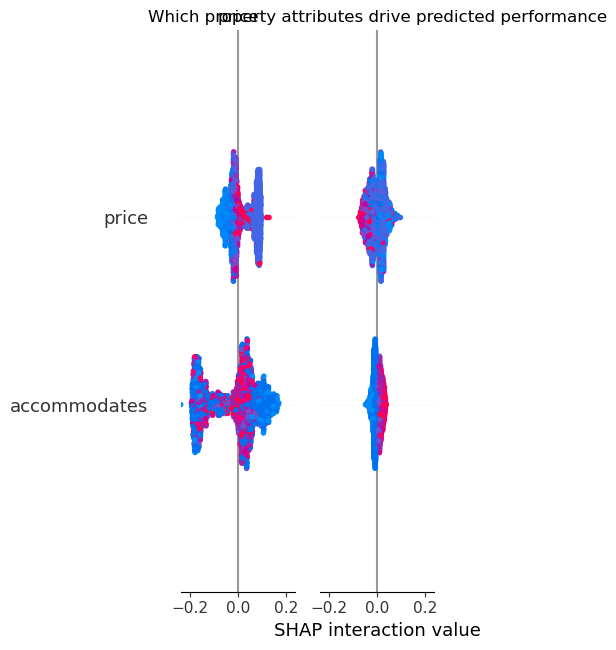

In [8]:
import shap
explainer = shap.TreeExplainer(rf)
sample = x_test.sample(2000, random_state=42)
shap_values = explainer.shap_values(sample)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.summary_plot(sv, sample, plot_type='bar', show=False)
plt.title('Which property attributes drive predicted performance')
plt.tight_layout(); plt.show()

## Deployment Recommendation

** Recommended use**
[What decision it supports and how it fits the workflow - e.g. scoring candidate properties to rank which are worth viewing, as one input alongside  survey and yield analysis. Note is uses only pre-purchase attributes, which is what makes it usable at alll.]

** What is must be used for **
[Automatic accept/reject without human review. pricing decisions -it predicts booking volume, not revenue. Individual host assessment. Anythingoutside London or a different market period.]

**Confidence and Limitations**
[ROC-AUC and recall in plain terms: of 100 genuinely high-performing properties, roughly how many does it flag? Then the honest ceiling: the target is built from Inside Airbnb's *estimated* occupancy, Which is itself derived from review counts - so the model predicts an estimate, not measured bookings.Also: bias check foundfrom Step 8]

** Conditions before production use**
[two to three specific ones, Suggestions to adapt:
-Validate predications against the companys own booking data for properties they already manage, before trusting it on acquistions
-Set a decision threshold deliberately based on the cost of a missed opportunity versus a wasted viewing, rather than defaulting to 0.5
-Address any group where recall was materially lower, or restrict use to segments where performance is even]

**Monitoring requirements**
[Name them concretely: retrain on each new Inside Airbnb snapshot (quarterly); track recall by borough and room type each cycle to catch drift; review performance after any regulatory change to London short-let rules, since the 90-night rule shapes the whole market]

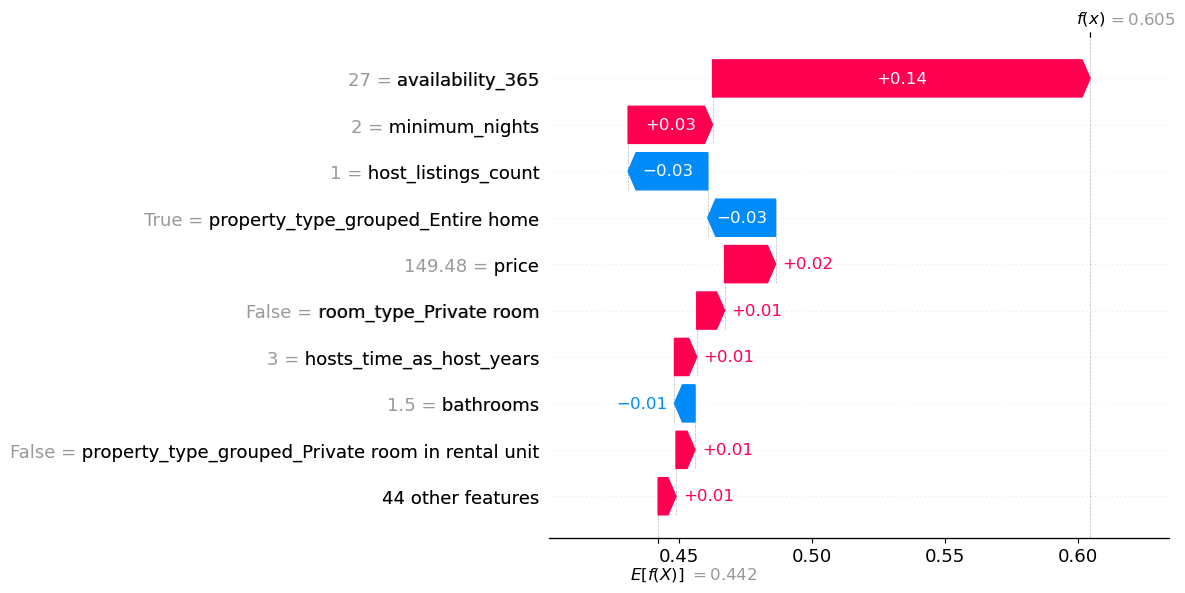

In [9]:
# Individual prediction explanation — SHAP waterfall for one listing
i = 0
shap.plots.waterfall(
    shap.Explanation(
        values=sv[i][:, 1],
        base_values=explainer.expected_value[1],
        data=sample.iloc[i],
        feature_names=sample.columns.tolist()
    )
)

Reading this Prediction: For this listings the model predicted 0.605(above the 0.442 baseline), classifying it as a high performer. The biggest driver was low yearly availability (availability_365 = 27, +0.14) - a listings thats rarely free reads as high-demand. Minimum nights and a moderate £149 price pushed the score up futher, while the hosts listing count pulled it down slightly.This lets a portfolio manager see the exact reasons behind any single flag, not just the outcpme.

In [10]:
[c for c in listings.columns if 'occupancy' in c]

['estimated_occupancy_l365d']

In [11]:
import os
print(os.path.abspath('05_ml.ipynb'))

C:\Users\K Mohan Raju\Untitled Folder 1\london-airbnb-analysis\notebooks\05_ml.ipynb
